# Chapter 1: Curves in the plane and in space

Source orientation: Pressley, Chapter 1, printed pages 1-27; PDF pages 11-37; sections 1.1-1.5.

This notebook is an original standalone teaching version of the assigned span. It uses the PDF only to orient the chapter structure and terminology. It does not reproduce textbook prose, exercise text, figures, screenshots, page crops, or page layouts.

## Chapter Question

When does a drawn curve behave like the path of a moving point, when does a parameter give trustworthy tangent and length data, and where do image-based descriptions fail because of singularities or self-intersections?

## Computational Translation Guide

| Chapter idea | Computational translation | What will be checked |
| --- | --- | --- |
| Level curve `f(x, y)=c` | A contour or zero set sampled on a grid, plus residuals `f(gamma(t))-c` for candidate parametrizations. | Level residuals and nonzero gradient tests. |
| Parametrized curve `gamma(t)` | A vector-valued function sampled with its derivative, speed, and image. | Derivative formulas, speed minima, and image residuals. |
| Tangent vector | The limiting direction of secants, computed as `gamma'(t)`. | Secant-to-tangent angle error and dot products. |
| Regularity and singularity | Regular means speed never vanishes; singular means the same image may lose tangent data at some parameter. | Symbolic speed squared and sampled speed minima. |
| Arc length and unit speed | The cumulative integral of speed and its inverse parameter. | Monotonicity of `s(t)` and numerical unit-speed residuals. |
| Reparametrization | Composition `gamma(phi(u))` with a smooth inverse; speed scales by `abs(phi'(u))`. | Chain-rule residual and the failure when `phi'` vanishes. |
| Closed curves and self-intersections | Period residuals and pairs of distinct parameter values with equal image points. | Period residuals and duplicate-point residuals. |
| Local level/parametrized passage | Nonzero gradient or nonzero coordinate derivative gives a local graph. | Gradient normal to tangent and cusp failure check. |

## Route

1. Compare level sets and parametrized paths without treating them as interchangeable.
2. Inspect tangents, speeds, regular points, and singular points on the same visible image.
3. Build arc length as a measurable function and use it to reparametrize a curve by distance.
4. Separate closedness from merely returning to a point, then inspect self-intersections.
5. Use the nonzero-gradient and inverse-function conditions to pass locally between implicit and parametrized descriptions.
6. Run an applied lab and final sanity checks so the core identities remain executable.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.integrate import cumulative_trapezoid
import sympy as sp
import plotly.graph_objects as go
from IPython.display import display


def find_book_root() -> Path:
    starts = [Path.cwd().resolve()]
    for rel in [Path("Elementary-Differential-Geometry-Andrew-Pressley"), Path(".."), Path("../..")]:
        candidate = (Path.cwd() / rel).resolve()
        if candidate not in starts:
            starts.append(candidate)
    for start in starts:
        for candidate in [start, *start.parents]:
            if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("Could not find the Pressley book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_json

UNIT = "chapter-01"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
UNIT_ARTIFACT_ROOT = ARTIFACT_ROOT / UNIT
for subdir in ["figures", "interactive", "checks", "tables"]:
    (UNIT_ARTIFACT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})

PALETTE = {
    "blue": "#2f6f9f",
    "green": "#3f7d5c",
    "red": "#b24a3b",
    "gold": "#c58b2d",
    "purple": "#7157a8",
    "gray": "#5f6770",
    "black": "#1f252d",
}

generated_artifacts = []
checks = {}
symbolic_checks = {}
SOURCE_SPAN = {"printed": "1-27", "pdf": "11-37", "sections": "1.1-1.5"}


def record(path):
    path = Path(path)
    if path not in generated_artifacts:
        generated_artifacts.append(path)
    return path


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


def save_figure(fig, filename):
    path = artifact_path(UNIT, "figures", filename, root=ARTIFACT_ROOT)
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return record(path)


def axis_equal(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, color="#c8d0d9", lw=0.8, zorder=0)
    ax.axvline(0, color="#c8d0d9", lw=0.8, zorder=0)


def image_stats(path):
    arr = np.asarray(Image.open(path).convert("RGB"), dtype=float)
    return {"width": int(arr.shape[1]), "height": int(arr.shape[0]), "pixel_std": float(arr.std())}


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {UNIT_ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Elementary-Differential-Geometry-Andrew-Pressley
Artifact root: artifacts\chapter-01


## Visual Storyboard

Each artifact is tied to a Chapter 1 concept and to a measurable invariant. Matplotlib is used for plane-curve comparisons because tangent directions, level residuals, singularities, and self-intersections are easiest to annotate in the plane. Plotly is used for the twisted cubic because spatial rotation is the natural inspection mode for a curve in `R^3`. SymPy handles exact derivative and chain-rule identities; NumPy and SciPy handle sampled speed and arc-length computations.


In [2]:
STORYBOARD = {
    "chapter_goal": "Connect level curves and parametrized curves, then identify the regularity and locality conditions that make tangent vectors, arc length, reparametrization, and closed-curve language reliable.",
    "source_span": SOURCE_SPAN,
    "visual_sequence": [
        {"artifact": "parametrized-level-coverage.png", "concept": "level set versus path coverage", "inspection_target": "same equation, different parameter coverage and speed behavior", "validation": "level residuals"},
        {"artifact": "tangent-regularity-singularity.png", "concept": "secants, tangents, regularity, and cusp data", "inspection_target": "where speed vanishes and what derivative still records", "validation": "symbolic speed and cusp determinant"},
        {"artifact": "arc-length-unit-speed.png", "concept": "arc length as a preferred parameter", "inspection_target": "equal-parameter versus equal-distance samples", "validation": "unit-speed residual"},
        {"artifact": "twisted-cubic-speed.html", "concept": "a regular curve in space", "inspection_target": "speed-colored 3D path and tangent directions", "validation": "positive speed formula"},
        {"artifact": "closed-curves-self-intersections.png", "concept": "closed curves and self-intersections", "inspection_target": "period residuals versus duplicate image points", "validation": "period and self-hit residuals"},
        {"artifact": "local-level-parametrized-passage.png", "concept": "local passage between implicit and parametrized descriptions", "inspection_target": "gradient normal and local graph condition", "validation": "tangent-gradient dot product and cusp gradient failure"},
    ],
    "library_routing": [
        {"concept": "plane curves", "library": "Matplotlib + NumPy", "why": "direct contours, paths, arrows, and residual overlays"},
        {"concept": "space curve", "library": "Plotly", "why": "interactive 3D rotation exposes the path and tangent directions"},
        {"concept": "identities", "library": "SymPy", "why": "exact speed, chain-rule, and cusp determinant checks"},
        {"concept": "arc length", "library": "SciPy + NumPy", "why": "cumulative integration and sampled unit-speed residuals"},
    ],
    "proof_visualization_strategy": "Use invariant ledgers: derivative identities, speed scaling under composition, period residuals, duplicate-point residuals, and gradient/tangent orthogonality expose the proof state.",
}

source_span_path = record(save_json(SOURCE_SPAN, UNIT, "checks", "source-span.json", root=ARTIFACT_ROOT))
storyboard_path = record(save_json(STORYBOARD, UNIT, "checks", "visual-storyboard.json", root=ARTIFACT_ROOT))
pd.DataFrame(STORYBOARD["visual_sequence"])


,artifact,concept,inspection_target,validation
0,parametrized-level-coverage.png,level set versus path coverage,"same equation, different parameter coverage an...",level residuals
1,tangent-regularity-singularity.png,"secants, tangents, regularity, and cusp data",where speed vanishes and what derivative still...,symbolic speed and cusp determinant
2,arc-length-unit-speed.png,arc length as a preferred parameter,equal-parameter versus equal-distance samples,unit-speed residual
3,twisted-cubic-speed.html,a regular curve in space,speed-colored 3D path and tangent directions,positive speed formula
4,closed-curves-self-intersections.png,closed curves and self-intersections,period residuals versus duplicate image points,period and self-hit residuals
5,local-level-parametrized-passage.png,local passage between implicit and parametrize...,gradient normal and local graph condition,tangent-gradient dot product and cusp gradient...


## 1. Level Sets And Parametrized Paths

A level equation describes a set of points. A parametrization describes how a moving point visits points. The two descriptions can agree on the image while disagreeing on coverage, speed, and tangent data. In the first artifact, inspect the residuals: the plotted path sits on the level set when the residual is small, but coverage and parameter behavior still require separate checks.


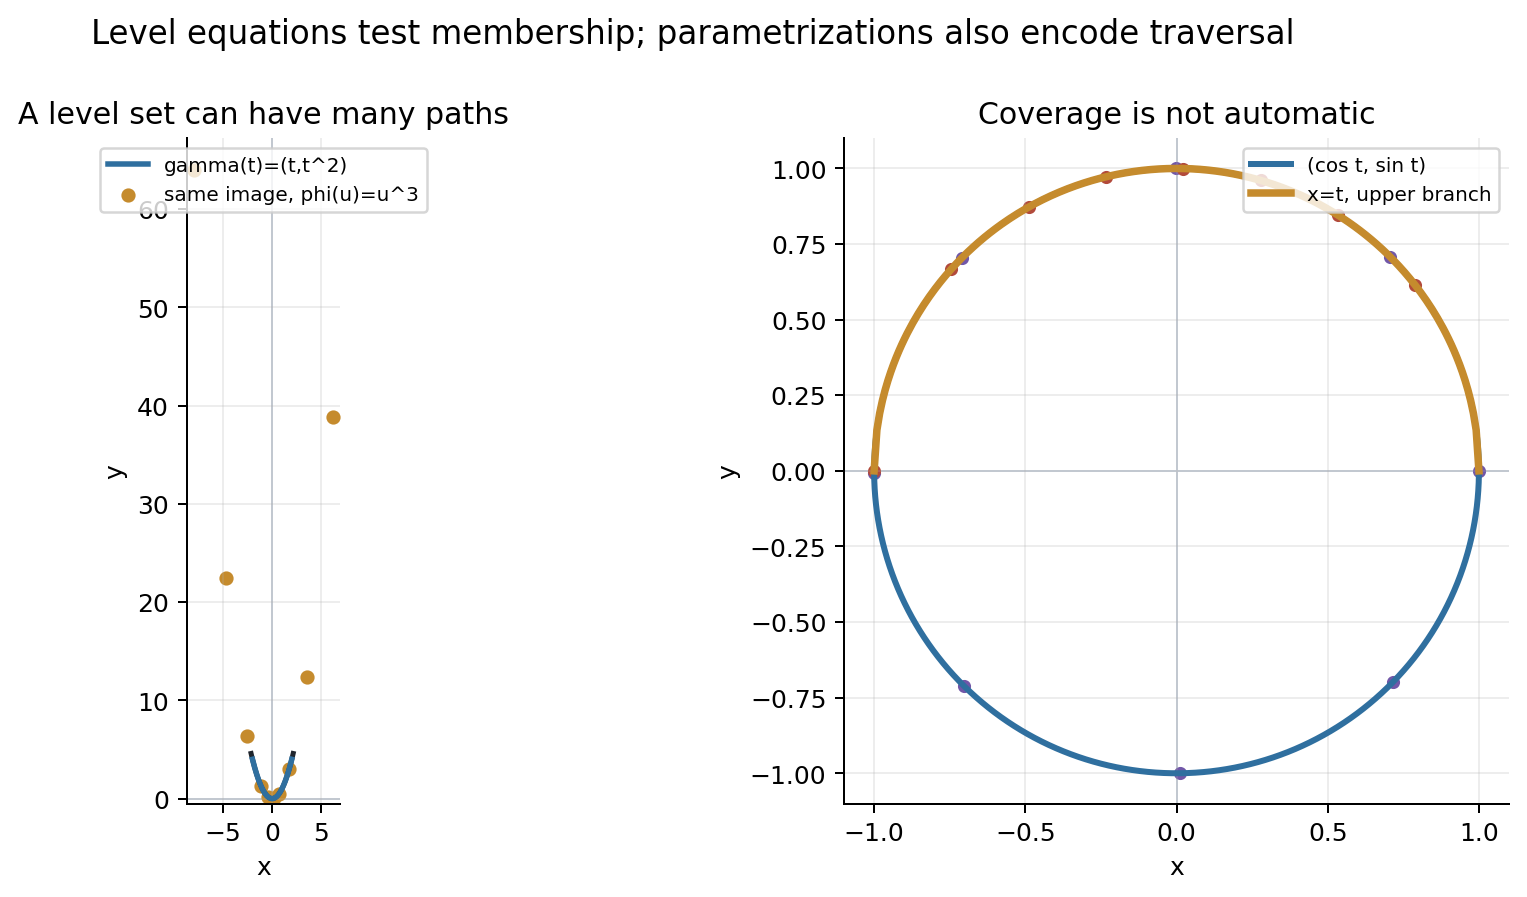

{'regular_parabola_level_residual_max': 0.0,
 'slow_parabola_level_residual_max': 7.105427357601002e-15,
 'trig_circle_level_residual_max': 2.220446049250313e-16,
 'upper_branch_min_y': 0.0,
 'trig_circle_min_y': -0.9999946230209747}

In [3]:
xx = np.linspace(-2.2, 2.2, 360)
yy = np.linspace(-0.5, 5.2, 320)
X, Y = np.meshgrid(xx, yy)
F_parabola = Y - X**2
t = np.linspace(-2.0, 2.0, 401)
parabola_regular = np.column_stack([t, t**2])
parabola_slow = np.column_stack([t**3, t**6])

u = np.linspace(0, 2 * np.pi, 480)
circle = np.column_stack([np.cos(u), np.sin(u)])
x_upper = np.linspace(-1, 1, 220)
upper_branch = np.column_stack([x_upper, np.sqrt(np.maximum(0, 1 - x_upper**2))])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.contour(X, Y, F_parabola, levels=[0], colors=[PALETTE["black"]], linewidths=2.0)
ax.plot(parabola_regular[:, 0], parabola_regular[:, 1], color=PALETTE["blue"], lw=2.2, label="gamma(t)=(t,t^2)")
ax.scatter(parabola_slow[::32, 0], parabola_slow[::32, 1], s=22, color=PALETTE["gold"], label="same image, phi(u)=u^3")
for sample in [-1.4, -0.4, 0.8, 1.5]:
    point = np.array([sample, sample**2])
    tangent = np.array([1.0, 2.0 * sample])
    tangent = 0.28 * tangent / np.linalg.norm(tangent)
    ax.arrow(point[0], point[1], tangent[0], tangent[1], color=PALETTE["red"], width=0.01, head_width=0.07, length_includes_head=True)
ax.set_title("A level set can have many paths")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(loc="upper center", fontsize=8)

ax = axes[1]
ax.plot(circle[:, 0], circle[:, 1], color=PALETTE["blue"], lw=2.4, label="(cos t, sin t)")
ax.plot(upper_branch[:, 0], upper_branch[:, 1], color=PALETTE["gold"], lw=3.0, label="x=t, upper branch")
ax.scatter(circle[::60, 0], circle[::60, 1], s=18, color=PALETTE["purple"])
ax.scatter(upper_branch[::28, 0], upper_branch[::28, 1], s=18, color=PALETTE["red"])
ax.set_title("Coverage is not automatic")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(loc="upper right", fontsize=8)
fig.suptitle("Level equations test membership; parametrizations also encode traversal", y=1.02, fontsize=13)
level_path = save_figure(fig, "parametrized-level-coverage.png")

param_level_checks = {
    "regular_parabola_level_residual_max": float(np.max(np.abs(parabola_regular[:, 1] - parabola_regular[:, 0] ** 2))),
    "slow_parabola_level_residual_max": float(np.max(np.abs(parabola_slow[:, 1] - parabola_slow[:, 0] ** 2))),
    "trig_circle_level_residual_max": float(np.max(np.abs(circle[:, 0] ** 2 + circle[:, 1] ** 2 - 1))),
    "upper_branch_min_y": float(upper_branch[:, 1].min()),
    "trig_circle_min_y": float(circle[:, 1].min()),
}
checks["parametrized_level"] = param_level_checks
display_artifact(level_path, width=920)
param_level_checks


## 2. Tangent Vectors, Regularity, And Singularities

The derivative is a tangent vector at a parameter value. Regularity is the condition that this vector is never zero. The same geometric image can be regular under one parameter and singular under another, so regularity is a property of the parametrized curve, not just the visible set.


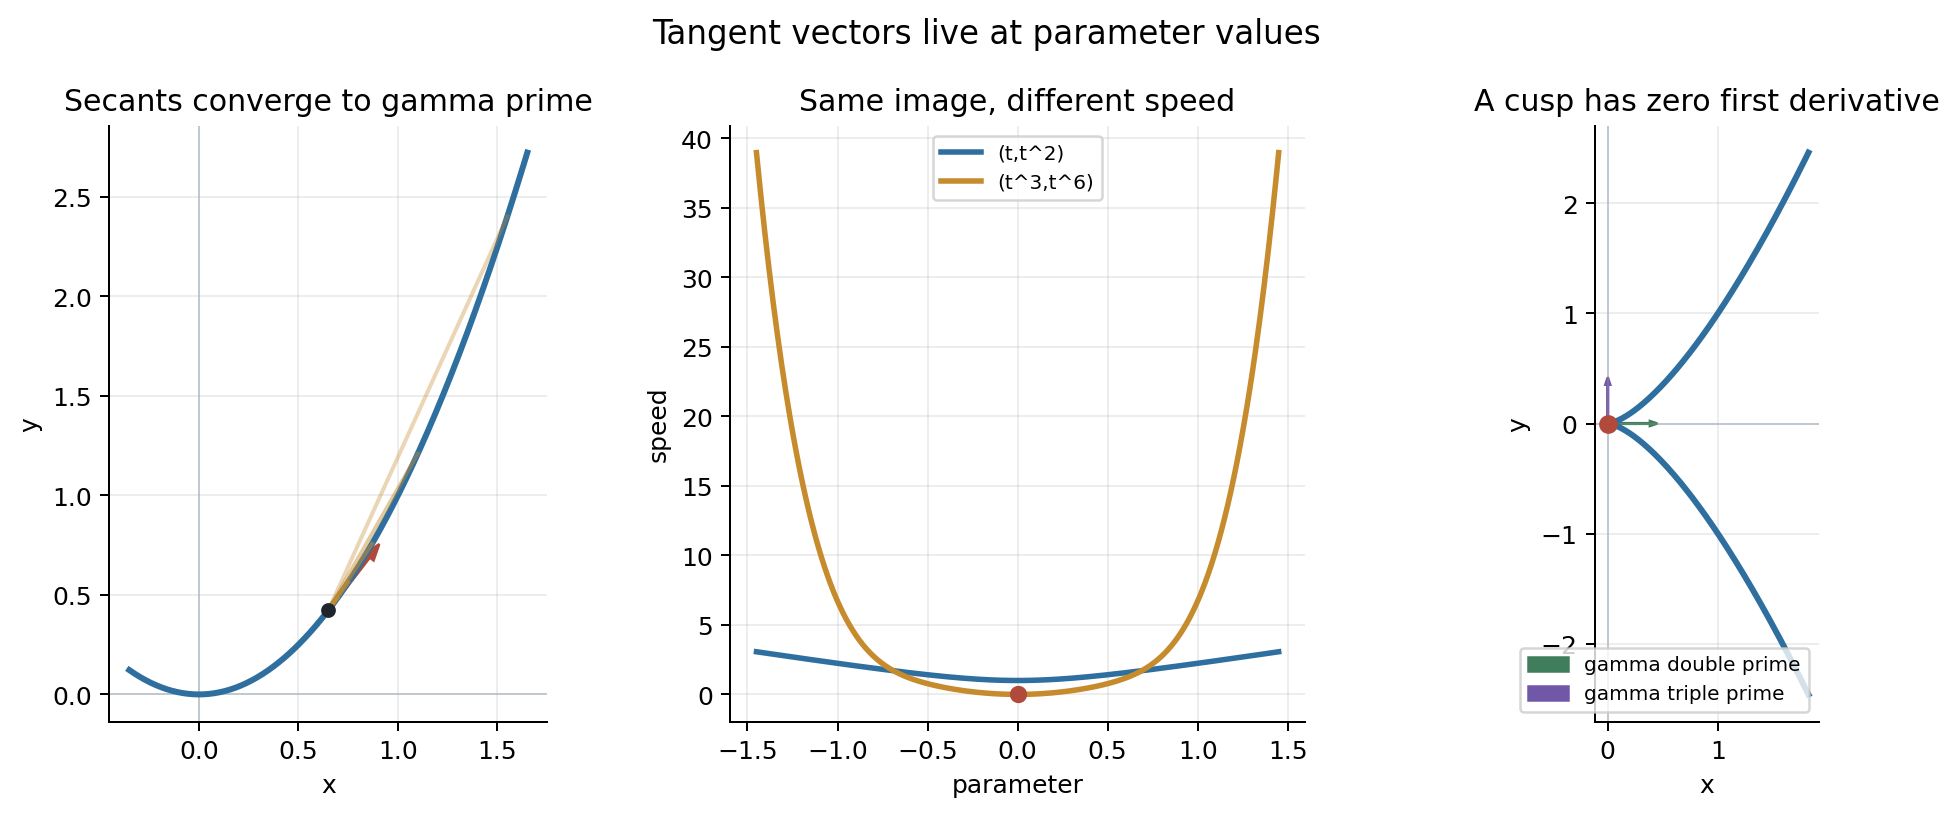

,identity,value
0,regular_parabola_speed_sq,4*t**2 + 1
1,slow_parabola_speed_sq,t**4*(36*t**6 + 9)
2,slow_speed_sq_at_zero,0
3,cusp_first_derivative_at_zero,"[0, 0]"
4,cusp_second_third_det_at_zero,12
5,chain_rule_speed_sq_residual,0
6,phi_prime_at_zero,0


In [4]:
t_sym, u_sym = sp.symbols("t u", real=True)
regular_gamma = sp.Matrix([t_sym, t_sym**2])
regular_velocity = regular_gamma.diff(t_sym)
regular_speed_sq = sp.simplify(regular_velocity.dot(regular_velocity))
slow_gamma = sp.Matrix([t_sym**3, t_sym**6])
slow_velocity = slow_gamma.diff(t_sym)
slow_speed_sq = sp.simplify(slow_velocity.dot(slow_velocity))
cusp_gamma = sp.Matrix([t_sym**2, t_sym**3])
cusp_v1 = cusp_gamma.diff(t_sym).subs(t_sym, 0)
cusp_v2 = cusp_gamma.diff(t_sym, 2).subs(t_sym, 0)
cusp_v3 = cusp_gamma.diff(t_sym, 3).subs(t_sym, 0)
cusp_det = sp.Matrix.hstack(cusp_v2, cusp_v3).det()

phi = u_sym**3
composed = sp.Matrix([phi, phi**2])
composed_velocity = composed.diff(u_sym)
chain_velocity = regular_velocity.subs(t_sym, phi) * sp.diff(phi, u_sym)
chain_speed_sq_residual = sp.simplify(composed_velocity.dot(composed_velocity) - regular_speed_sq.subs(t_sym, phi) * sp.diff(phi, u_sym) ** 2)

symbolic_checks.update({
    "regular_parabola_speed_sq": str(regular_speed_sq),
    "slow_parabola_speed_sq": str(slow_speed_sq),
    "slow_speed_sq_at_zero": int(slow_speed_sq.subs(t_sym, 0)),
    "cusp_first_derivative_at_zero": [int(v) for v in cusp_v1],
    "cusp_second_third_det_at_zero": int(cusp_det),
    "chain_rule_speed_sq_residual": str(chain_speed_sq_residual),
    "phi_prime_at_zero": int(sp.diff(phi, u_sym).subs(u_sym, 0)),
})

t0 = 0.65
base = np.array([t0, t0**2])
tangent = np.array([1.0, 2.0 * t0])
tangent_unit = tangent / np.linalg.norm(tangent)
deltas = np.array([0.9, 0.45, 0.22, 0.10, 0.045])
angle_errors = []
secant_segments = []
for delta in deltas:
    nearby = np.array([t0 + delta, (t0 + delta) ** 2])
    sec = (nearby - base) / np.linalg.norm(nearby - base)
    angle_errors.append(float(np.degrees(np.arccos(np.clip(np.dot(sec, tangent_unit), -1, 1)))))
    secant_segments.append(np.vstack([base, nearby]))

s = np.linspace(-1.45, 1.45, 501)
regular_speed = np.sqrt(1 + 4 * s**2)
slow_speed = np.sqrt(9 * s**4 + 36 * s**10)
c = np.linspace(-1.35, 1.35, 400)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
ax = axes[0]
curve_t = np.linspace(-0.35, 1.65, 300)
ax.plot(curve_t, curve_t**2, color=PALETTE["blue"], lw=2.4)
for i, seg in enumerate(secant_segments):
    ax.plot(seg[:, 0], seg[:, 1], color=PALETTE["gold"], alpha=0.35 + 0.11 * i, lw=1.6)
ax.arrow(base[0], base[1], 0.42 * tangent_unit[0], 0.42 * tangent_unit[1], color=PALETTE["red"], width=0.008, head_width=0.055, length_includes_head=True)
ax.scatter([base[0]], [base[1]], color=PALETTE["black"], s=24, zorder=5)
ax.set_title("Secants converge to gamma prime")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)

ax = axes[1]
ax.plot(s, regular_speed, color=PALETTE["blue"], lw=2.2, label="(t,t^2)")
ax.plot(s, slow_speed, color=PALETTE["gold"], lw=2.2, label="(t^3,t^6)")
ax.scatter([0], [0], color=PALETTE["red"], s=35, zorder=5)
ax.set_title("Same image, different speed")
ax.set_xlabel("parameter")
ax.set_ylabel("speed")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(c**2, c**3, color=PALETTE["blue"], lw=2.4)
ax.scatter([0], [0], color=PALETTE["red"], s=42, zorder=5)
ax.arrow(0, 0, 0.45, 0, color=PALETTE["green"], width=0.006, head_width=0.045, length_includes_head=True, label="gamma double prime")
ax.arrow(0, 0, 0, 0.42, color=PALETTE["purple"], width=0.006, head_width=0.045, length_includes_head=True, label="gamma triple prime")
ax.set_title("A cusp has zero first derivative")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(fontsize=8, loc="lower right")
fig.suptitle("Tangent vectors live at parameter values", y=1.02, fontsize=13)
tangent_path = save_figure(fig, "tangent-regularity-singularity.png")

regularity_checks = {
    "secant_angle_errors_degrees": angle_errors,
    "finest_secant_angle_error_degrees": angle_errors[-1],
    "regular_parabola_min_speed_on_sample": float(regular_speed.min()),
    "slow_parabola_speed_at_zero": float(slow_speed[np.argmin(np.abs(s))]),
    "cusp_second_third_det": int(cusp_det),
    "chain_rule_speed_sq_residual_zero": bool(chain_speed_sq_residual == 0),
}
checks["regularity"] = regularity_checks
exact_checks_path = record(save_json(symbolic_checks, UNIT, "checks", "exact-symbolic-checks.json", root=ARTIFACT_ROOT))
display_artifact(tangent_path, width=940)
pd.DataFrame([{"identity": key, "value": value} for key, value in symbolic_checks.items()])


## 3. Arc Length And Unit-Speed Parameters

Arc length adds up the small segment lengths `||gamma'(t)|| dt`. On a regular curve this cumulative function is smooth and strictly monotone, so it can be inverted locally and used as a parameter. The logarithmic spiral is useful here because its speed and arc length have explicit formulas, while the plot still shows why equal steps in the old parameter are not equal distances along the image.


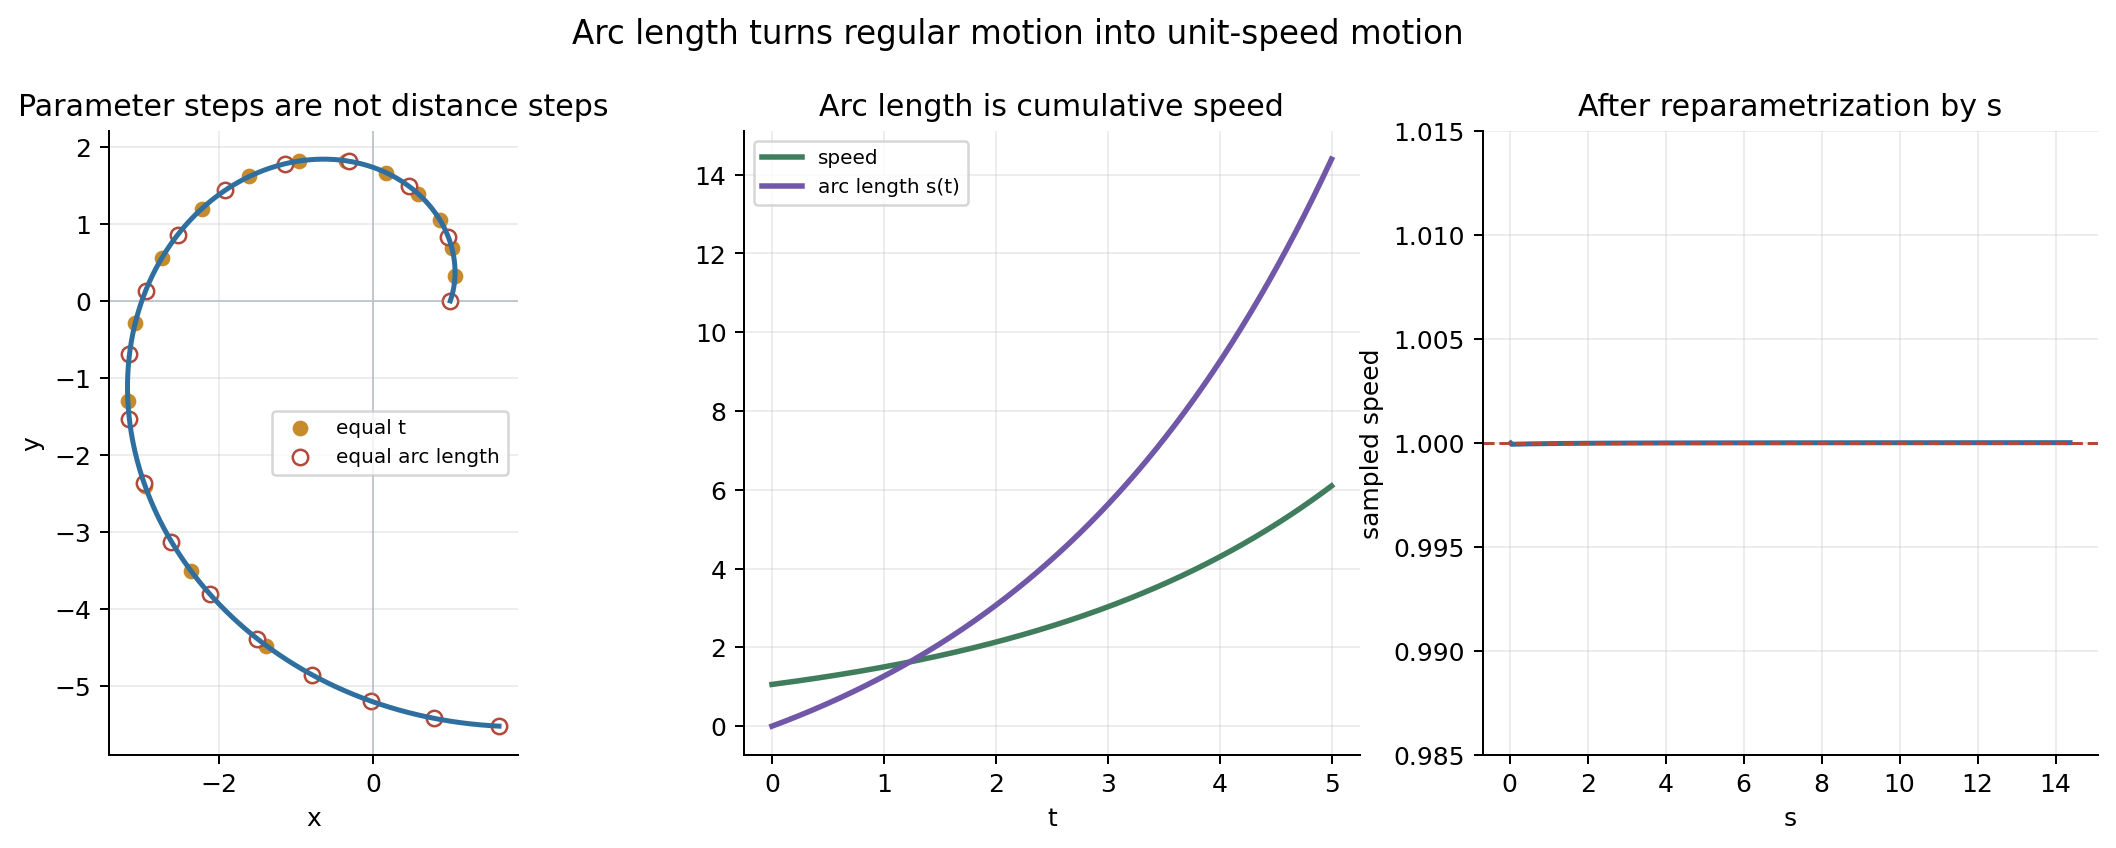

{'arc_formula_vs_numeric_max_abs': 8.720567862496864e-06,
 'arc_length_monotone': True,
 'unit_speed_max_abs_error': 7.759603598911369e-05,
 'unit_speed_mean_abs_error': 1.374135674462873e-05,
 'spiral_speed_identity_zero': True}

In [5]:
k = 0.35
t_vals = np.linspace(0, 5.0, 650)
spiral = np.column_stack([np.exp(k * t_vals) * np.cos(t_vals), np.exp(k * t_vals) * np.sin(t_vals)])
speed_formula = np.sqrt(1 + k**2) * np.exp(k * t_vals)
s_numeric = cumulative_trapezoid(speed_formula, t_vals, initial=0.0)
s_formula = np.sqrt(1 + k**2) / k * (np.exp(k * t_vals) - 1)
equal_t = np.linspace(t_vals.min(), t_vals.max(), 18)
equal_t_points = np.column_stack([np.exp(k * equal_t) * np.cos(equal_t), np.exp(k * equal_t) * np.sin(equal_t)])
equal_s = np.linspace(0, s_formula[-1], 18)
t_from_s = (1 / k) * np.log(1 + k * equal_s / np.sqrt(1 + k**2))
equal_s_points = np.column_stack([np.exp(k * t_from_s) * np.cos(t_from_s), np.exp(k * t_from_s) * np.sin(t_from_s)])

s_dense = np.linspace(0.02, s_formula[-1] - 0.02, 620)
t_s = (1 / k) * np.log(1 + k * s_dense / np.sqrt(1 + k**2))
x_s = np.exp(k * t_s) * np.cos(t_s)
y_s = np.exp(k * t_s) * np.sin(t_s)
unit_speed_numeric = np.sqrt(np.gradient(x_s, s_dense) ** 2 + np.gradient(y_s, s_dense) ** 2)
unit_speed_error = np.abs(unit_speed_numeric - 1)

k_sym = sp.symbols("k", positive=True)
spiral_sym = sp.Matrix([sp.exp(k_sym * t_sym) * sp.cos(t_sym), sp.exp(k_sym * t_sym) * sp.sin(t_sym)])
spiral_speed_sq = sp.simplify(spiral_sym.diff(t_sym).dot(spiral_sym.diff(t_sym)))
spiral_speed_identity = sp.simplify(spiral_speed_sq - (1 + k_sym**2) * sp.exp(2 * k_sym * t_sym))
symbolic_checks["spiral_speed_sq_identity_residual"] = str(spiral_speed_identity)
exact_checks_path = record(save_json(symbolic_checks, UNIT, "checks", "exact-symbolic-checks.json", root=ARTIFACT_ROOT))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax = axes[0]
ax.plot(spiral[:, 0], spiral[:, 1], color=PALETTE["blue"], lw=2.0)
ax.scatter(equal_t_points[:, 0], equal_t_points[:, 1], color=PALETTE["gold"], s=28, label="equal t")
ax.scatter(equal_s_points[:, 0], equal_s_points[:, 1], facecolor="white", edgecolor=PALETTE["red"], s=38, label="equal arc length")
ax.set_title("Parameter steps are not distance steps")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(t_vals, speed_formula, color=PALETTE["green"], lw=2.2, label="speed")
ax.plot(t_vals, s_formula, color=PALETTE["purple"], lw=2.2, label="arc length s(t)")
ax.set_title("Arc length is cumulative speed")
ax.set_xlabel("t")
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(s_dense, unit_speed_numeric, color=PALETTE["blue"], lw=2.0)
ax.axhline(1.0, color=PALETTE["red"], lw=1.2, ls="--")
ax.set_ylim(0.985, 1.015)
ax.set_title("After reparametrization by s")
ax.set_xlabel("s")
ax.set_ylabel("sampled speed")
fig.suptitle("Arc length turns regular motion into unit-speed motion", y=1.02, fontsize=13)
arc_path = save_figure(fig, "arc-length-unit-speed.png")

arc_checks = {
    "arc_formula_vs_numeric_max_abs": float(np.max(np.abs(s_formula - s_numeric))),
    "arc_length_monotone": bool(np.all(np.diff(s_formula) > 0)),
    "unit_speed_max_abs_error": float(unit_speed_error.max()),
    "unit_speed_mean_abs_error": float(unit_speed_error.mean()),
    "spiral_speed_identity_zero": bool(spiral_speed_identity == 0),
}
checks["arc_length"] = arc_checks
display_artifact(arc_path, width=940)
arc_checks


## 4. Reparametrization And A Space Curve

A reparametrization is not just any composition. The reparametrization map must have a smooth inverse, so its derivative cannot vanish. The composition `gamma(u^3)` traces the same parabola image as `gamma(t)=(t,t^2)`, but it is not a valid reparametrization across the origin because the speed scaling factor collapses there.

The same regularity test applies in space. The twisted cubic `gamma(t)=(t,t^2,t^3)` has speed squared `1+4t^2+9t^4`, so it is regular even though its arc length is not elementary. Rotate the Plotly artifact to inspect that tangent vectors live in 3D, not in a projection.


In [6]:
reparam_table = pd.DataFrame([
    {"object": "gamma(t)", "formula": "(t, t^2)", "speed_squared": str(regular_speed_sq), "status": "regular for every t"},
    {"object": "phi(u)", "formula": "u^3", "speed_squared": "not a curve", "status": "phi prime vanishes at u=0; inverse is not smooth there"},
    {"object": "gamma(phi(u))", "formula": "(u^3, u^6)", "speed_squared": str(sp.simplify(composed_velocity.dot(composed_velocity))), "status": "same image, singular at u=0"},
])

t3 = np.linspace(-2.0, 2.0, 360)
pts3 = np.column_stack([t3, t3**2, t3**3])
speed3 = np.sqrt(1 + 4 * t3**2 + 9 * t3**4)
fig3 = go.Figure()
fig3.add_trace(go.Scatter3d(
    x=pts3[:, 0], y=pts3[:, 1], z=pts3[:, 2],
    mode="lines",
    line=dict(color=speed3, colorscale="Viridis", width=7, colorbar=dict(title="speed")),
    name="twisted cubic",
))
for sample in [-1.6, -0.6, 0.6, 1.6]:
    p = np.array([sample, sample**2, sample**3])
    v = np.array([1.0, 2.0 * sample, 3.0 * sample**2])
    v = 0.38 * v / np.linalg.norm(v)
    seg = np.vstack([p - v, p + v])
    fig3.add_trace(go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode="lines", line=dict(color="#b24a3b", width=5), showlegend=False))
fig3.update_layout(title="Twisted cubic: regular space curve with speed-colored trace", scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="data"), margin=dict(l=0, r=0, b=0, t=45), height=560)
html_path = record(artifact_path(UNIT, "interactive", "twisted-cubic-speed.html", root=ARTIFACT_ROOT))
fig3.write_html(str(html_path), include_plotlyjs=True, full_html=True)

twisted_speed_sym = sp.Matrix([t_sym, t_sym**2, t_sym**3]).diff(t_sym)
twisted_speed_sq = sp.simplify(twisted_speed_sym.dot(twisted_speed_sym))
symbolic_checks["twisted_cubic_speed_sq"] = str(twisted_speed_sq)
exact_checks_path = record(save_json(symbolic_checks, UNIT, "checks", "exact-symbolic-checks.json", root=ARTIFACT_ROOT))

space_checks = {
    "twisted_cubic_speed_sq": str(twisted_speed_sq),
    "twisted_cubic_min_sample_speed": float(speed3.min()),
    "twisted_cubic_speed_positive": bool(speed3.min() > 0),
    "reparam_chain_rule_residual_zero": bool(chain_speed_sq_residual == 0),
    "invalid_reparam_phi_prime_at_zero": int(sp.diff(phi, u_sym).subs(u_sym, 0)),
}
checks["space_and_reparametrization"] = space_checks
display(reparam_table)
display_artifact(html_path, width="100%", height=560)
space_checks


,object,formula,speed_squared,status
0,gamma(t),"(t, t^2)",4*t**2 + 1,regular for every t
1,phi(u),u^3,not a curve,phi prime vanishes at u=0; inverse is not smoo...
2,gamma(phi(u)),"(u^3, u^6)",u**4*(36*u**6 + 9),"same image, singular at u=0"


{'twisted_cubic_speed_sq': '9*t**4 + 4*t**2 + 1',
 'twisted_cubic_min_sample_speed': 1.0000620751727916,
 'twisted_cubic_speed_positive': True,
 'reparam_chain_rule_residual_zero': True,
 'invalid_reparam_phi_prime_at_zero': 0}

## 5. Closed Curves And Self-Intersections

Closed means the whole parametrized curve is periodic. A self-intersection means two genuinely different parameter values share one image point, after excluding the trivial repeats caused by a period. The limacon panel marks the same geometric point reached with two tangent vectors. That is the warning behind the chapter's careful language: a tangent vector belongs first to a parameter value.


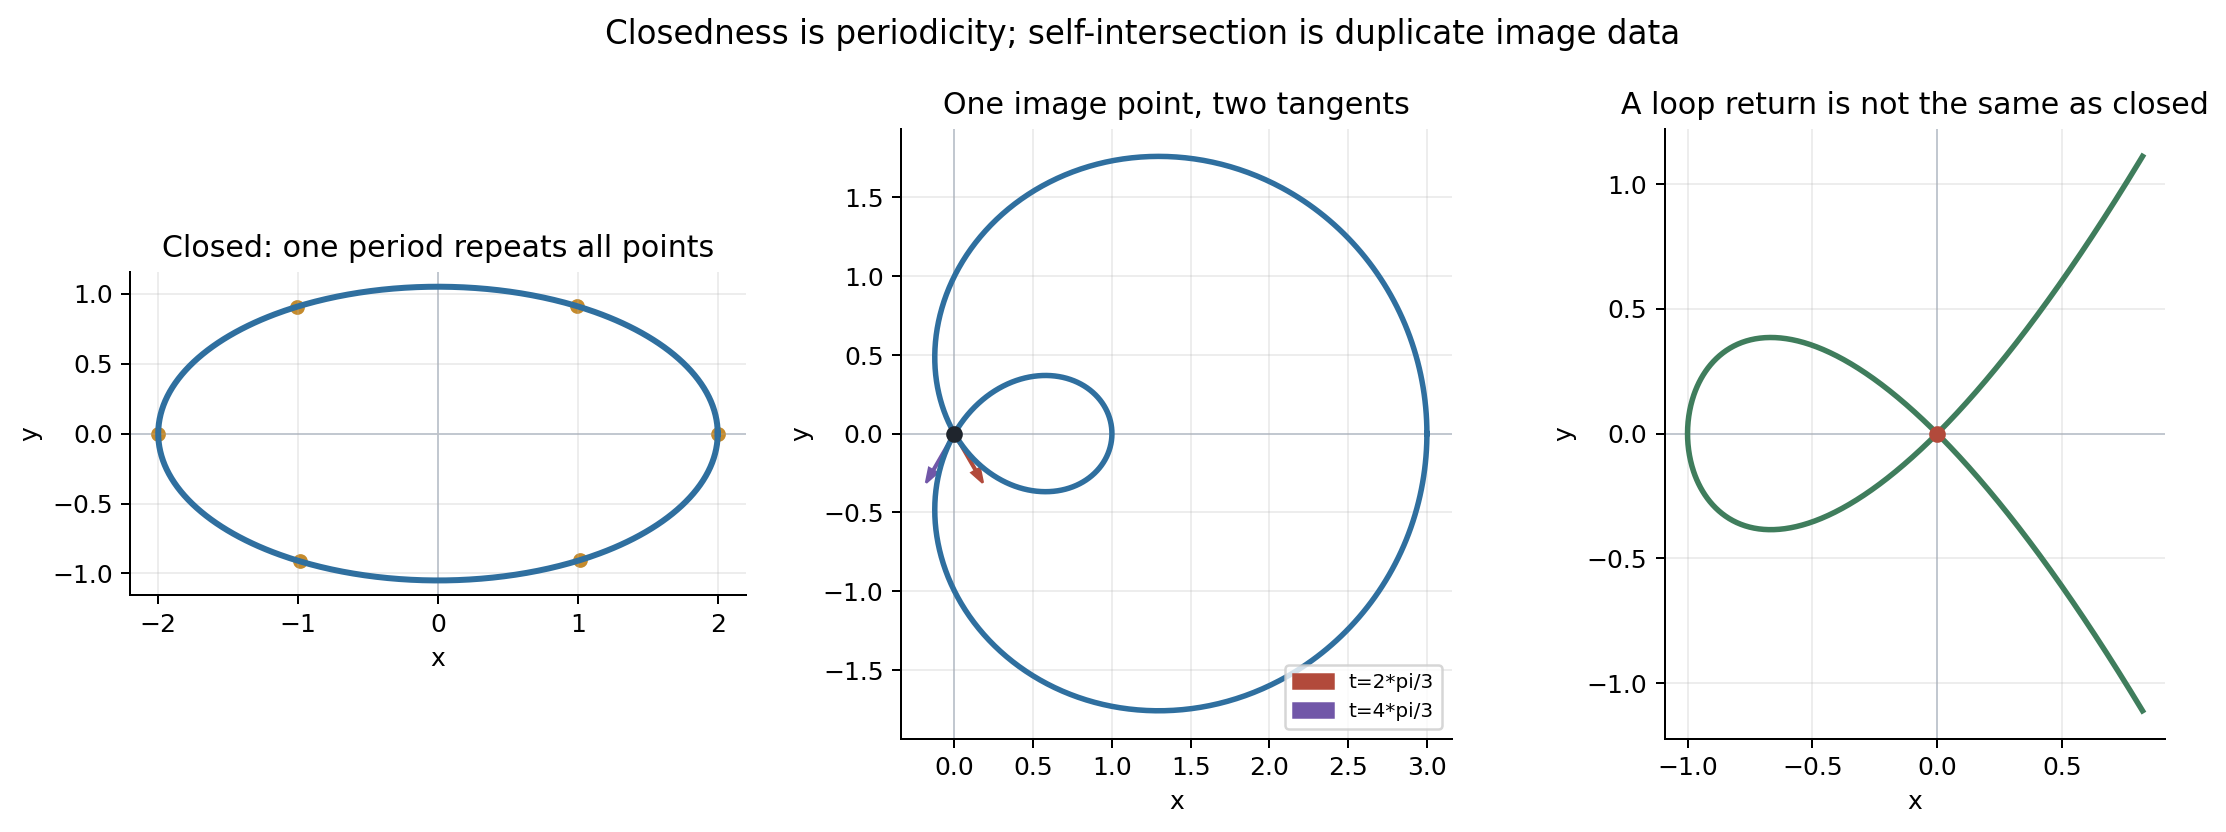

{'ellipse_period_residual_max': 2.1812421540521875e-15,
 'limacon_self_intersection_distance': 7.691850745534258e-16,
 'limacon_parameter_difference_over_period': 0.3333333333333333,
 'limacon_tangent_angle_degrees': 60.000000000000036,
 'loop_origin_duplicate_distance': 0.0}

In [7]:
tc = np.linspace(0, 2 * np.pi, 600)
ellipse = np.column_stack([2.0 * np.cos(tc), 1.05 * np.sin(tc)])
ellipse_shifted = np.column_stack([2.0 * np.cos(tc + 2 * np.pi), 1.05 * np.sin(tc + 2 * np.pi)])

def limacon(theta):
    return np.column_stack([(1 + 2 * np.cos(theta)) * np.cos(theta), (1 + 2 * np.cos(theta)) * np.sin(theta)])


def limacon_velocity(theta):
    return np.column_stack([-np.sin(theta) - 2 * np.sin(2 * theta), np.cos(theta) + 2 * np.cos(2 * theta)])


tl = np.linspace(0, 2 * np.pi, 900)
lim = limacon(tl)
t_a, t_b = 2 * np.pi / 3, 4 * np.pi / 3
p_a = limacon(np.array([t_a]))[0]
p_b = limacon(np.array([t_b]))[0]
v_a = limacon_velocity(np.array([t_a]))[0]
v_b = limacon_velocity(np.array([t_b]))[0]
angle = float(np.degrees(np.arccos(np.clip(np.dot(v_a, v_b) / (np.linalg.norm(v_a) * np.linalg.norm(v_b)), -1, 1))))

tl_loop = np.linspace(-1.35, 1.35, 600)
loop = np.column_stack([tl_loop**2 - 1, tl_loop**3 - tl_loop])
loop_a = np.array([0.0, 0.0])
loop_b = np.array([0.0, 0.0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
ax = axes[0]
ax.plot(ellipse[:, 0], ellipse[:, 1], color=PALETTE["blue"], lw=2.4)
ax.scatter(ellipse[::100, 0], ellipse[::100, 1], color=PALETTE["gold"], s=24)
ax.set_title("Closed: one period repeats all points")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)

ax = axes[1]
ax.plot(lim[:, 0], lim[:, 1], color=PALETTE["blue"], lw=2.2)
ax.scatter([0], [0], color=PALETTE["black"], s=32, zorder=5)
for v, color, label in [(v_a, PALETTE["red"], "t=2*pi/3"), (v_b, PALETTE["purple"], "t=4*pi/3")]:
    vv = 0.36 * v / np.linalg.norm(v)
    ax.arrow(0, 0, vv[0], vv[1], width=0.01, head_width=0.06, color=color, length_includes_head=True, label=label)
ax.set_title("One image point, two tangents")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(fontsize=8, loc="lower right")

ax = axes[2]
ax.plot(loop[:, 0], loop[:, 1], color=PALETTE["green"], lw=2.2)
ax.scatter([0], [0], color=PALETTE["red"], s=32, zorder=5)
ax.set_title("A loop return is not the same as closed")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
fig.suptitle("Closedness is periodicity; self-intersection is duplicate image data", y=1.02, fontsize=13)
closed_path = save_figure(fig, "closed-curves-self-intersections.png")

closed_checks = {
    "ellipse_period_residual_max": float(np.max(np.linalg.norm(ellipse - ellipse_shifted, axis=1))),
    "limacon_self_intersection_distance": float(np.linalg.norm(p_a - p_b)),
    "limacon_parameter_difference_over_period": float((t_b - t_a) / (2 * np.pi)),
    "limacon_tangent_angle_degrees": angle,
    "loop_origin_duplicate_distance": float(np.linalg.norm(loop_a - loop_b)),
}
checks["closed_self_intersections"] = closed_checks
display_artifact(closed_path, width=940)
closed_checks


## 6. Local Passage Between Level And Parametrized Descriptions

The local bridge has two complementary tests. For a level curve `f(x,y)=0`, a nonzero gradient gives a normal vector, and the tangent direction is perpendicular to it. If one partial derivative is nonzero, the level set locally looks like a graph. For a regular parametrized plane curve, if one coordinate derivative is nonzero, that coordinate can be used locally as a parameter and the image can be written as a level curve.

The third panel shows why the hypotheses matter: at a cusp of `y^2=x^3`, the gradient of the level equation vanishes at the origin, so the ordinary local graph argument has no regular tangent model there.


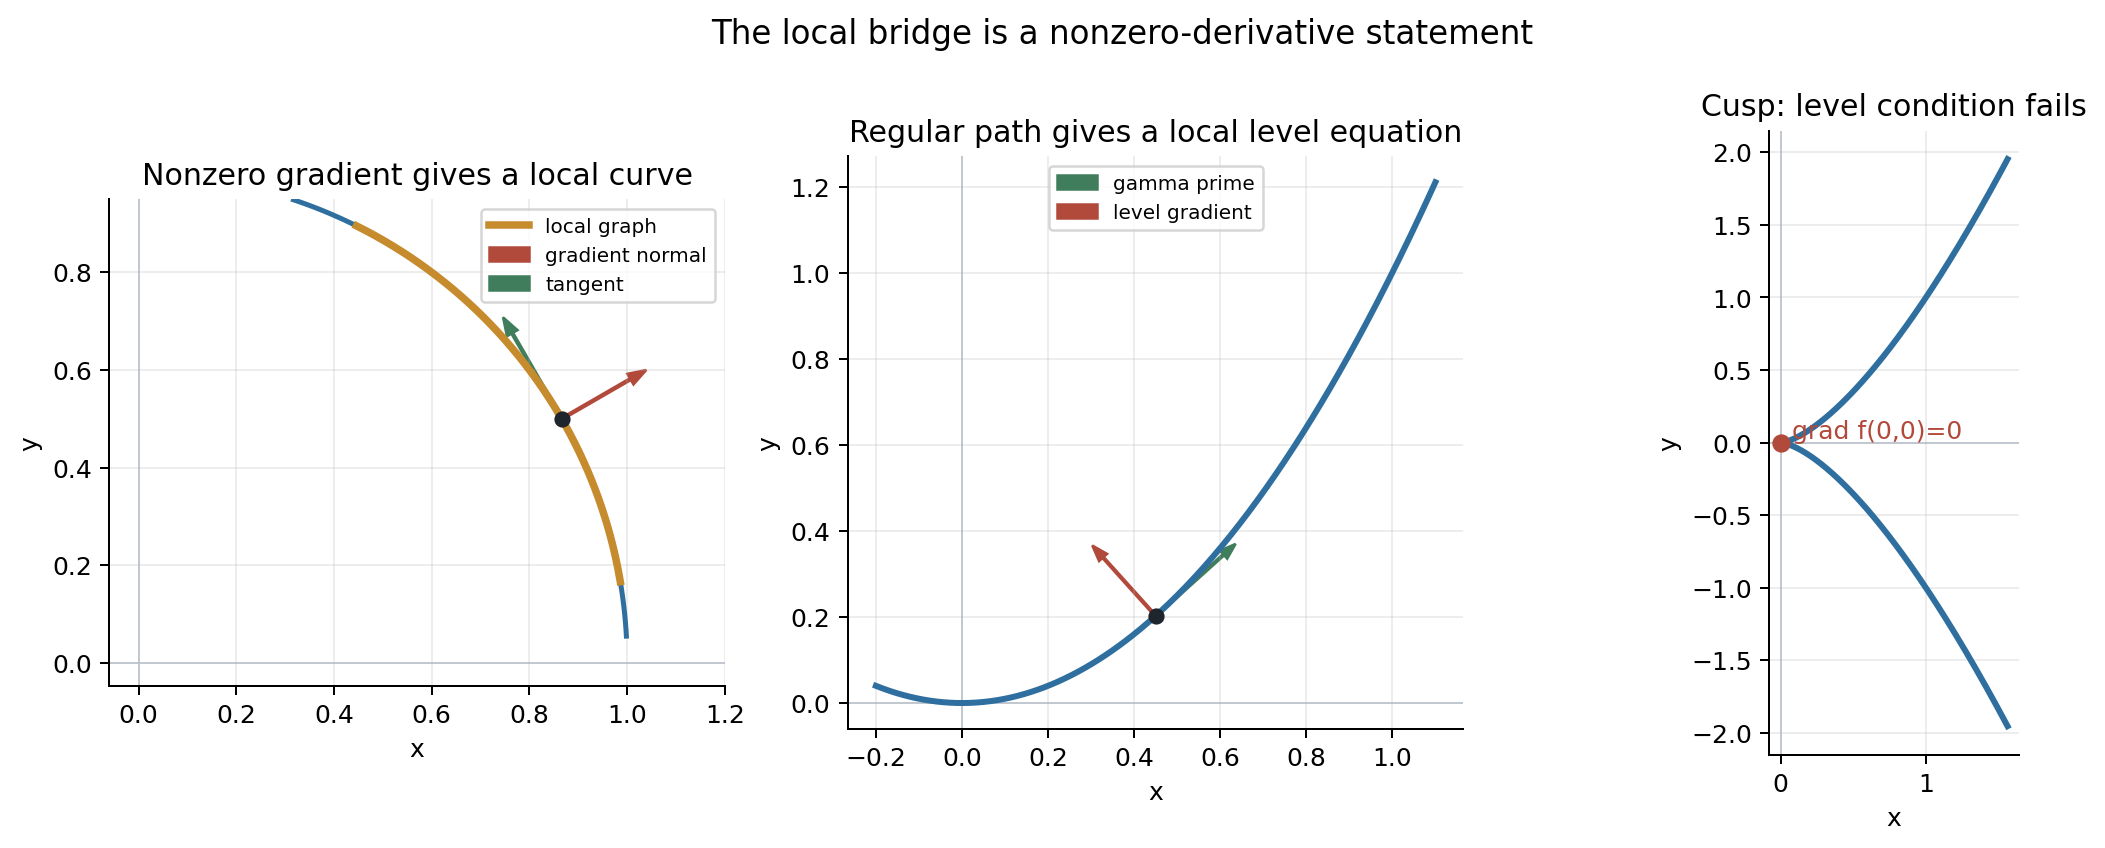

{'circle_level_residual_on_branch_max': 2.220446049250313e-16,
 'circle_gradient_norm_at_p': 1.9999999999999998,
 'circle_tangent_dot_gradient': 0.0,
 'parabola_level_residual_on_patch_max': 0.0,
 'parabola_tangent_dot_level_gradient': 0.0,
 'cusp_level_gradient_norm_at_origin': 0.0}

In [8]:
p = np.array([np.sqrt(3) / 2, 0.5])
grad = np.array([2 * p[0], 2 * p[1]])
tangent_circle = np.array([-grad[1], grad[0]])
tangent_circle_unit = tangent_circle / np.linalg.norm(tangent_circle)
xs_local = np.linspace(p[0] - 0.42, p[0] + 0.12, 220)
y_branch = np.sqrt(1 - xs_local**2)

t0_local = 0.45
x_patch = np.linspace(t0_local - 0.65, t0_local + 0.65, 250)
y_patch = x_patch**2
parabola_grad_at = np.array([-2 * t0_local, 1.0])
parabola_tangent_at = np.array([1.0, 2 * t0_local])
cusp_t = np.linspace(-1.25, 1.25, 500)
cusp_pts = np.column_stack([cusp_t**2, cusp_t**3])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax = axes[0]
xl = np.linspace(0.2, 1.2, 280)
yl = np.linspace(0.05, 0.95, 260)
XL, YL = np.meshgrid(xl, yl)
ax.contour(XL, YL, XL**2 + YL**2 - 1, levels=[0], colors=[PALETTE["blue"]], linewidths=2.0)
ax.plot(xs_local, y_branch, color=PALETTE["gold"], lw=3.0, label="local graph")
ax.scatter([p[0]], [p[1]], color=PALETTE["black"], s=30, zorder=5)
ax.arrow(p[0], p[1], 0.2 * grad[0] / np.linalg.norm(grad), 0.2 * grad[1] / np.linalg.norm(grad), color=PALETTE["red"], width=0.004, head_width=0.025, length_includes_head=True, label="gradient normal")
ax.arrow(p[0], p[1], 0.24 * tangent_circle_unit[0], 0.24 * tangent_circle_unit[1], color=PALETTE["green"], width=0.004, head_width=0.025, length_includes_head=True, label="tangent")
ax.set_title("Nonzero gradient gives a local curve")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(x_patch, y_patch, color=PALETTE["blue"], lw=2.4)
point = np.array([t0_local, t0_local**2])
ax.scatter([point[0]], [point[1]], color=PALETTE["black"], s=30, zorder=5)
ax.arrow(point[0], point[1], 0.25 * parabola_tangent_at[0] / np.linalg.norm(parabola_tangent_at), 0.25 * parabola_tangent_at[1] / np.linalg.norm(parabola_tangent_at), color=PALETTE["green"], width=0.004, head_width=0.025, length_includes_head=True, label="gamma prime")
ax.arrow(point[0], point[1], 0.22 * parabola_grad_at[0] / np.linalg.norm(parabola_grad_at), 0.22 * parabola_grad_at[1] / np.linalg.norm(parabola_grad_at), color=PALETTE["red"], width=0.004, head_width=0.025, length_includes_head=True, label="level gradient")
ax.set_title("Regular path gives a local level equation")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(cusp_pts[:, 0], cusp_pts[:, 1], color=PALETTE["blue"], lw=2.4)
ax.scatter([0], [0], color=PALETTE["red"], s=40, zorder=5)
ax.text(0.08, 0.03, "grad f(0,0)=0", color=PALETTE["red"])
ax.set_title("Cusp: level condition fails")
ax.set_xlabel("x")
ax.set_ylabel("y")
axis_equal(ax)
fig.suptitle("The local bridge is a nonzero-derivative statement", y=1.02, fontsize=13)
local_path = save_figure(fig, "local-level-parametrized-passage.png")

local_checks = {
    "circle_level_residual_on_branch_max": float(np.max(np.abs(xs_local**2 + y_branch**2 - 1))),
    "circle_gradient_norm_at_p": float(np.linalg.norm(grad)),
    "circle_tangent_dot_gradient": float(np.dot(tangent_circle, grad)),
    "parabola_level_residual_on_patch_max": float(np.max(np.abs(y_patch - x_patch**2))),
    "parabola_tangent_dot_level_gradient": float(np.dot(parabola_tangent_at, parabola_grad_at)),
    "cusp_level_gradient_norm_at_origin": 0.0,
}
checks["local_passage"] = local_checks
display_artifact(local_path, width=940)
local_checks


## Applied Lab: Diagnose A Curve Description

The lab below is intentionally small: change the entries in `LAB_CURVES` or add one of your own. The diagnostic table asks three Chapter 1 questions of each parametrized curve: does sampled speed vanish, does a proposed period repeat the whole curve, and does the curve have a known duplicate image point that should be treated as a self-intersection rather than as a single tangent direction?


In [9]:
def diagnostic_row(name, xy, dxy, interval, period=None, duplicate_pair=None):
    grid = np.linspace(interval[0], interval[1], 801)
    pts = xy(grid)
    vel = dxy(grid)
    speeds = np.linalg.norm(vel, axis=1)
    row = {
        "curve": name,
        "parameter_interval": f"[{interval[0]:.3g}, {interval[1]:.3g}]",
        "sample_min_speed": float(speeds.min()),
        "sample_regular": bool(speeds.min() > 1e-4),
        "period_residual": None,
        "duplicate_point_residual": None,
        "chapter_1_reading": "",
    }
    if period is not None:
        shifted = xy(grid + period)
        row["period_residual"] = float(np.max(np.linalg.norm(pts - shifted, axis=1)))
    if duplicate_pair is not None:
        a, b = duplicate_pair
        row["duplicate_point_residual"] = float(np.linalg.norm(xy(np.array([a]))[0] - xy(np.array([b]))[0]))
    if row["period_residual"] is not None and row["period_residual"] < 1e-8:
        row["chapter_1_reading"] = "closed on the proposed period"
    elif row["duplicate_point_residual"] is not None and row["duplicate_point_residual"] < 1e-8 and duplicate_pair[0] != duplicate_pair[1]:
        row["chapter_1_reading"] = "has a self-intersection or loop return"
    elif not row["sample_regular"]:
        row["chapter_1_reading"] = "singular parameter values appear in the sample"
    else:
        row["chapter_1_reading"] = "regular over the sampled interval"
    return row


LAB_CURVES = [
    ("regular parabola", lambda z: np.column_stack([z, z**2]), lambda z: np.column_stack([np.ones_like(z), 2 * z]), (-1.5, 1.5), None, None),
    ("slowed parabola", lambda z: np.column_stack([z**3, z**6]), lambda z: np.column_stack([3 * z**2, 6 * z**5]), (-1.5, 1.5), None, None),
    ("ellipse", lambda z: np.column_stack([2 * np.cos(z), np.sin(z)]), lambda z: np.column_stack([-2 * np.sin(z), np.cos(z)]), (0, 2 * np.pi), 2 * np.pi, None),
    ("limacon", limacon, limacon_velocity, (0, 2 * np.pi), 2 * np.pi, (2 * np.pi / 3, 4 * np.pi / 3)),
    ("semicubical cusp", lambda z: np.column_stack([z**2, z**3]), lambda z: np.column_stack([2 * z, 3 * z**2]), (-1.25, 1.25), None, (0, 0)),
]

lab_table = pd.DataFrame([
    diagnostic_row(name, xy, dxy, interval, period=period, duplicate_pair=duplicate_pair)
    for name, xy, dxy, interval, period, duplicate_pair in LAB_CURVES
])
lab_csv_path = record(artifact_path(UNIT, "tables", "applied-lab.csv", root=ARTIFACT_ROOT))
lab_table.to_csv(lab_csv_path, index=False)
invariants_path = record(save_json(checks, UNIT, "checks", "curve-invariants.json", root=ARTIFACT_ROOT))
display(lab_table)
print(f"Saved lab table to {rel(lab_csv_path)}")


,curve,parameter_interval,sample_min_speed,sample_regular,period_residual,duplicate_point_residual,chapter_1_reading
0,regular parabola,"[-1.5, 1.5]",1.0,True,NaN,NaN,regular over the sampled interval
1,slowed parabola,"[-1.5, 1.5]",0.0,False,NaN,NaN,singular parameter values appear in the sample
2,ellipse,"[0, 6.28]",1.0,True,2.278663e-15,NaN,closed on the proposed period
3,limacon,"[0, 6.28]",1.0,True,3.628663e-15,7.691851e-16,closed on the proposed period
4,semicubical cusp,"[-1.25, 1.25]",0.0,False,NaN,0.000000e+00,singular parameter values appear in the sample


Saved lab table to artifacts/chapter-01/tables/applied-lab.csv


## Final Sanity Checks

The final cell checks the core Chapter 1 invariants, verifies all generated artifacts exist and are nonempty, records image nonblank statistics, and confirms that the old generic visual helper is absent from this notebook.


In [10]:
assert param_level_checks["regular_parabola_level_residual_max"] < 1e-12
assert param_level_checks["slow_parabola_level_residual_max"] < 1e-12
assert param_level_checks["trig_circle_level_residual_max"] < 1e-12
assert regularity_checks["finest_secant_angle_error_degrees"] < regularity_checks["secant_angle_errors_degrees"][0]
assert regularity_checks["slow_parabola_speed_at_zero"] < 1e-2
assert regularity_checks["cusp_second_third_det"] != 0
assert arc_checks["arc_length_monotone"]
assert arc_checks["unit_speed_max_abs_error"] < 3e-3
assert space_checks["twisted_cubic_speed_positive"]
assert space_checks["reparam_chain_rule_residual_zero"]
assert closed_checks["ellipse_period_residual_max"] < 1e-12
assert closed_checks["limacon_self_intersection_distance"] < 1e-12
assert closed_checks["loop_origin_duplicate_distance"] < 1e-12
assert abs(local_checks["circle_tangent_dot_gradient"]) < 1e-12
assert abs(local_checks["parabola_tangent_dot_level_gradient"]) < 1e-12
assert local_checks["circle_gradient_norm_at_p"] > 0
assert local_checks["circle_level_residual_on_branch_max"] < 1e-12
assert local_checks["cusp_level_gradient_norm_at_origin"] == 0
assert symbolic_checks["spiral_speed_sq_identity_residual"] == "0"

min_bytes_by_suffix = {".png": 10_000, ".html": 10_000, ".json": 40, ".csv": 40}
artifact_summaries = []
for path in list(generated_artifacts):
    suffix = path.suffix.lower()
    assert_artifact(path, min_bytes=min_bytes_by_suffix.get(suffix, 1))
    item = {"path": rel(path), "bytes": path.stat().st_size}
    if suffix == ".png":
        item.update(image_stats(path))
        assert item["pixel_std"] > 1.0
    artifact_summaries.append(item)

notebook_path = BOOK_ROOT / "chapter-01-curves-in-the-plane-and-in-space" / "01-curves-in-the-plane-and-in-space.ipynb"
forbidden = "build_" + "unit_visuals"
assert forbidden not in notebook_path.read_text(encoding="utf-8")

final_sanity = {
    "source_span": SOURCE_SPAN,
    "core_checks": {
        "level_residuals_small": True,
        "regularity_and_cusp_checks_passed": True,
        "arc_length_unit_speed_checks_passed": True,
        "closed_and_self_intersection_checks_passed": True,
        "local_passage_checks_passed": True,
        "generic_visual_helper_absent": True,
    },
    "artifact_count_before_final_json": len(generated_artifacts),
    "artifacts": artifact_summaries,
    "lab_rows": int(len(lab_table)),
    "libraries_used": ["numpy", "scipy", "matplotlib", "plotly", "sympy", "pandas", "Pillow"],
}
final_path = record(save_json(final_sanity, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT))
notebook_sanity = {
    "unit": UNIT,
    "source_span": SOURCE_SPAN,
    "artifact_names": [rel(path) for path in generated_artifacts],
    "artifact_count": len(generated_artifacts),
    "lab_rows": int(len(lab_table)),
    "checks_recorded": sorted(checks.keys()),
    "generic_visual_helper_absent": True,
}
notebook_sanity_path = record(save_json(notebook_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT))
assert_artifact(final_path, min_bytes=200)
assert_artifact(notebook_sanity_path, min_bytes=200)
final_sanity["artifact_count"] = len(generated_artifacts)
final_sanity["artifact_names"] = [rel(path) for path in generated_artifacts]
save_json(final_sanity, UNIT, "checks", "final-sanity.json", root=ARTIFACT_ROOT)
notebook_sanity["artifact_names"] = [rel(path) for path in generated_artifacts]
notebook_sanity["artifact_count"] = len(generated_artifacts)
save_json(notebook_sanity, UNIT, "checks", "notebook-sanity.json", root=ARTIFACT_ROOT)
final_sanity


{'source_span': {'printed': '1-27', 'pdf': '11-37', 'sections': '1.1-1.5'},
 'core_checks': {'level_residuals_small': True,
  'regularity_and_cusp_checks_passed': True,
  'arc_length_unit_speed_checks_passed': True,
  'closed_and_self_intersection_checks_passed': True,
  'local_passage_checks_passed': True,
  'generic_visual_helper_absent': True},
 'artifact_count_before_final_json': 11,
 'artifacts': [{'path': 'artifacts/chapter-01/checks/source-span.json',
   'bytes': 70},
  {'path': 'artifacts/chapter-01/checks/visual-storyboard.json',
   'bytes': 2784},
  {'path': 'artifacts/chapter-01/figures/parametrized-level-coverage.png',
   'bytes': 99808,
   'width': 1527,
   'height': 897,
   'pixel_std': 35.89428350548782},
  {'path': 'artifacts/chapter-01/figures/tangent-regularity-singularity.png',
   'bytes': 118992,
   'width': 1957,
   'height': 815,
   'pixel_std': 35.87675285910262},
  {'path': 'artifacts/chapter-01/checks/exact-symbolic-checks.json',
   'bytes': 394},
  {'path': 'a

## Takeaways

- A level equation tests membership in a set; a parametrization also records how the set is traversed.
- Tangent vectors and speeds belong to parameter values. At self-intersections, one image point can carry multiple tangent vectors.
- Regularity is the condition that makes tangent direction and arc-length reparametrization dependable.
- Arc length is parameter-independent after orientation and additive constant choices; unit speed is the computational form of using distance as the parameter.
- A curve can close only when the whole parametrized curve is periodic. A loop return or duplicate image point is a self-intersection unless it comes from the period itself.
- The local equivalence between level and parametrized descriptions is a nonzero-derivative theorem: nonzero gradient for level curves and nonzero coordinate derivative for parametrized curves.
